# Human-LLM Judge Comparison Analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the combined data
df = pd.read_csv('comparison_results.csv')


In [78]:
# Define dimensions
dimensions = [
    'textual_groundedness',
    'hallucination_free',
    'concept_counting',
    'comprehensibility',
    'conciseness',
    'specificity',
    'discriminativeness',
    'instruction_following',
    'logical_coherence'
]

distance_cols = [f'dist_{dim}' for dim in dimensions]

# We need to calculate scores per dimension and trial.
# Let's melt the dataframe so we have one row per trial per dimension.
id_vars = ['item_id', 'dataset', 'condition', 'annotator']
# Keep only necessary columns for the melt
df_melted = df[id_vars + distance_cols].melt(id_vars=id_vars, value_vars=distance_cols, var_name='dimension', value_name='distance')

# Clean up dimension names
df_melted['dimension'] = df_melted['dimension'].str.replace('dist_', '')

# Calculate the score
def calculate_score(dist):
    if pd.isna(dist):
        return np.nan
    if dist == 0:
        return 1.0
    elif dist == 1:
        return 0.75
    else:
        return 0

df_melted['score'] = df_melted['distance'].apply(calculate_score)

df_melted.head()


,item_id,dataset,condition,annotator,dimension,distance,score
0,65,dtd,E3,nico,textual_groundedness,0.0,1.00
1,66,dtd,E3,nico,textual_groundedness,2.0,0.00
2,67,flowers,E3,nico,textual_groundedness,1.0,0.75
3,68,flowers,E3,nico,textual_groundedness,1.0,0.75
4,69,flowers,E3,nico,textual_groundedness,1.0,0.75


## Visualizations

/tmp/ipykernel_312833/3511702852.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_melted, x='annotator', y='score', errorbar=None, palette='Set2')


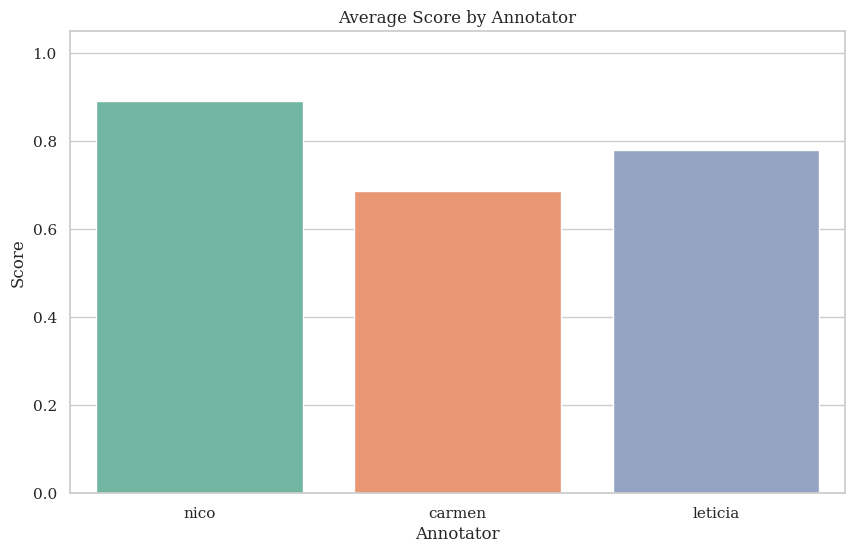

In [80]:
# 1. Visualization by Human Name (Annotator)
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='annotator', y='score', errorbar=None, palette='Set2')
plt.title('Average Score by Annotator')
plt.ylabel('Score')
plt.xlabel('Annotator')
plt.ylim(0, 1.05)
plt.show()


/tmp/ipykernel_312833/3288514906.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_melted, x='dimension', y='score', errorbar=None, palette='Set2')


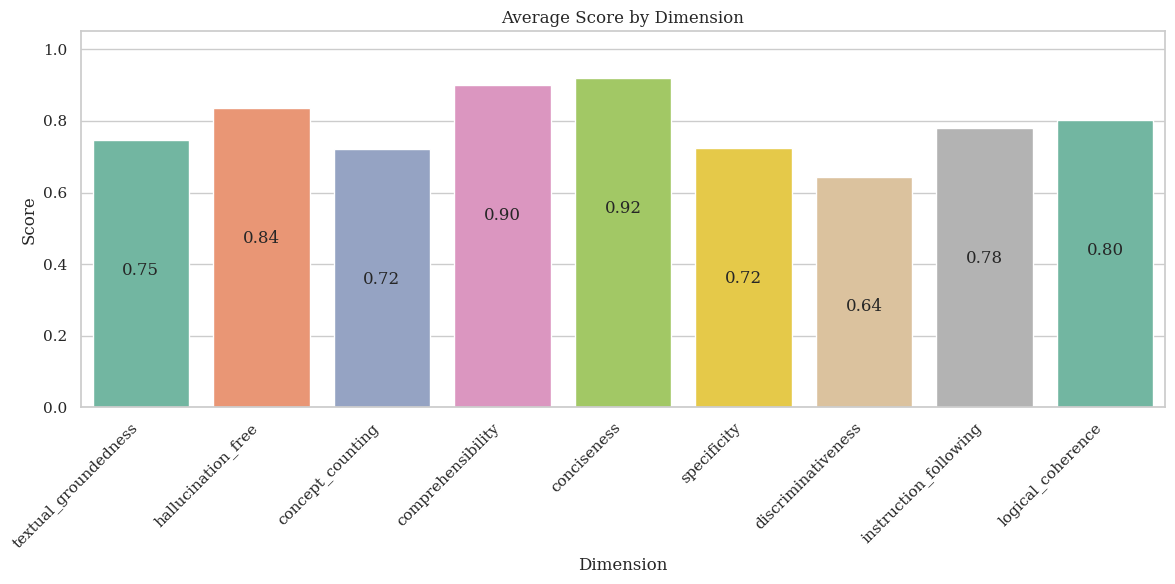

In [81]:
# 2. Visualization by Dimension Name
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman']

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_melted, x='dimension', y='score', errorbar=None, palette='Set2')
plt.title('Average Score by Dimension')
plt.ylabel('Score')
plt.xlabel('Dimension')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
# 2. Agregamos los valores a las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=-100)
plt.tight_layout()
plt.savefig('twa_score_by_dimension.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_312833/2469413779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_melted, x='condition', y='score',  palette='Set2', errorbar=None)


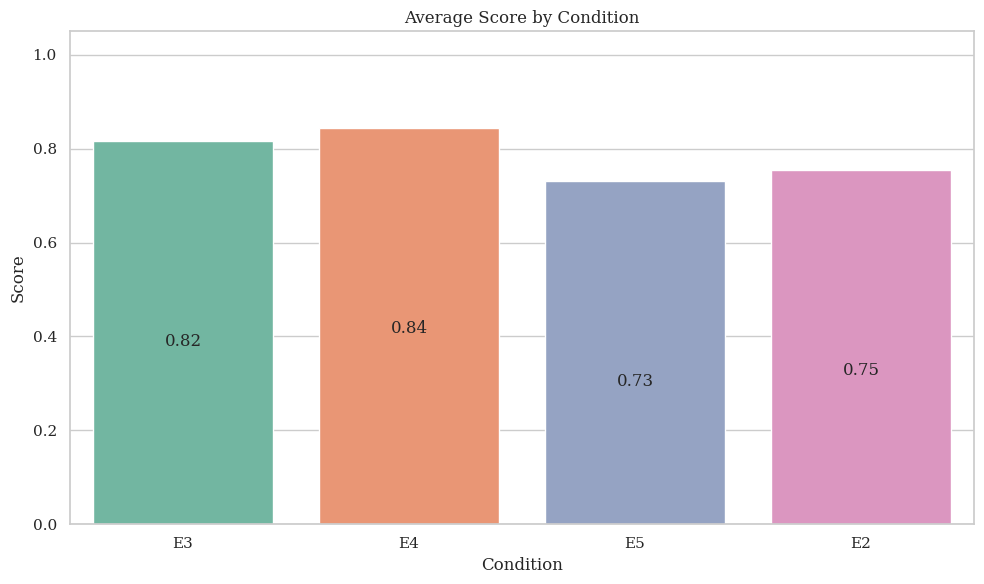

In [82]:
# 3. Visualization by Condition
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x='condition', y='score',  palette='Set2', errorbar=None)
plt.title('Average Score by Condition')
plt.ylabel('Score')
plt.xlabel('Condition')
plt.ylim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=-150)
plt.tight_layout()
plt.savefig('twa_score_by_condition.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_312833/4264750182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_melted, x='dataset', y='score', palette='Set2', errorbar=None)


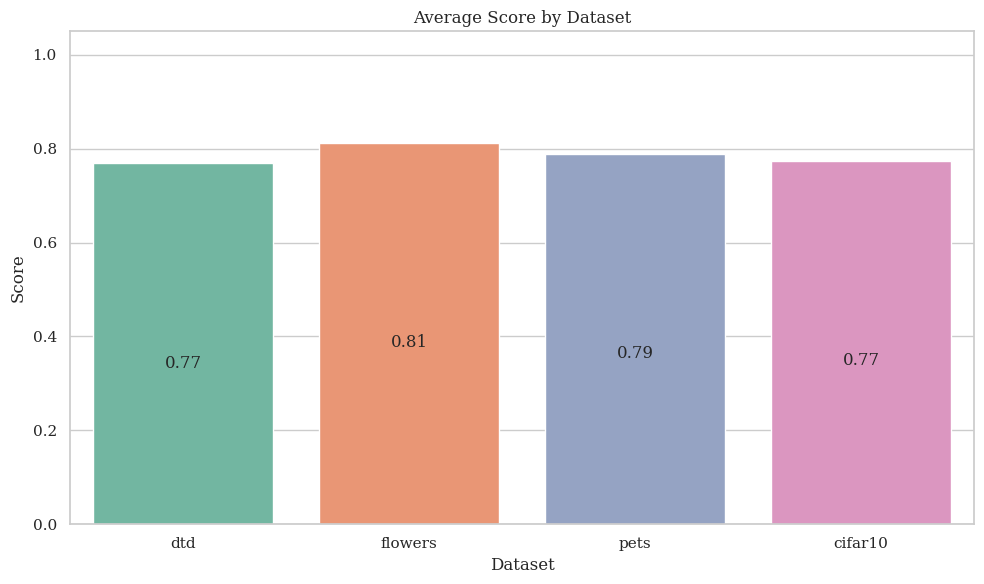

In [83]:
# 4. Visualization by Dataset
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x='dataset', y='score', palette='Set2', errorbar=None)
plt.title('Average Score by Dataset')
plt.ylabel('Score')
plt.xlabel('Dataset')
plt.ylim(0, 1.05)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=-150)
plt.tight_layout()
plt.savefig('twa_score_by_dataset.png', dpi=300, bbox_inches='tight')
plt.show()


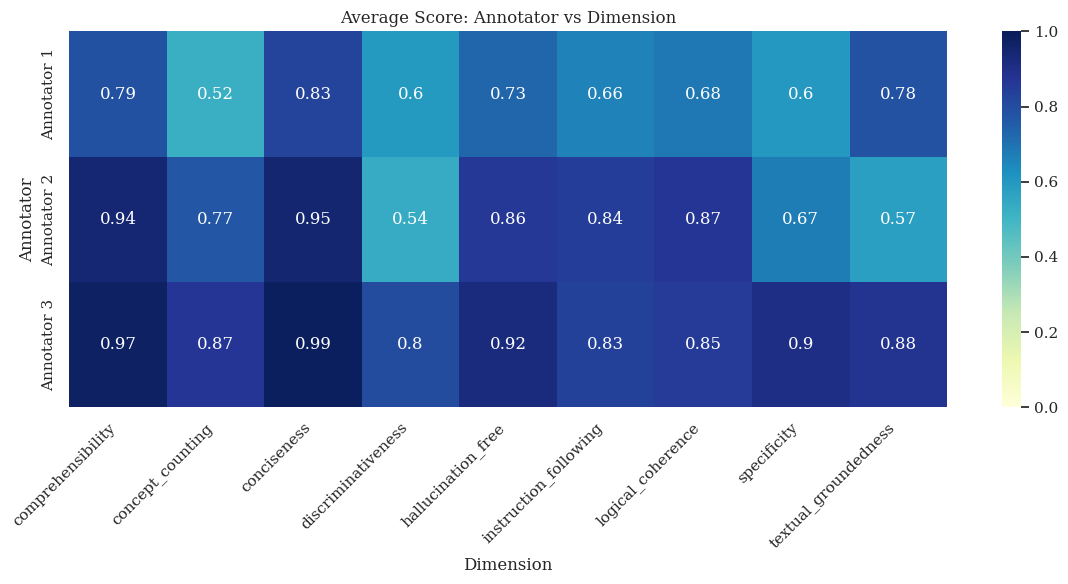

In [84]:
# Heatmap of Average Scores by Annotator and Dimension
pivot_df = df_melted.pivot_table(index='annotator', columns='dimension', values='score', aggfunc='mean')
pivot_df.index = [f'Annotator {i+1}' for i in range(len(pivot_df))]
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Average Score: Annotator vs Dimension')
plt.ylabel('Annotator')
plt.xlabel('Dimension')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('twa_score_by_annotator_dim.png', dpi=300, bbox_inches='tight')
plt.show()
